In [1]:
import pandas as pd
import numpy as np
import os
import network_utils

# Define the base path to the raw data
raw_dir = 'dataset/ogbn_arxiv/raw'
mapping_dir = 'dataset/ogbn_arxiv/mapping'

# 1. Load the Citation Edges (adjacency list)
# Format: source_node, target_node
edges = pd.read_csv(os.path.join(raw_dir, 'edge.csv.gz'), compression='gzip', header=None)
edges.columns = ['source', 'target']

# 2. Load the Node Features (128-dimensional embeddings)
# These are usually stored as a compressed CSV or NPY. OGB uses CSV.gz for raw.
node_feat = pd.read_csv(os.path.join(raw_dir, 'node-feat.csv.gz'), compression='gzip', header=None)

# 3. Load Node years
node_year = pd.read_csv(os.path.join(raw_dir, 'node_year.csv.gz'), compression='gzip', header=None)
node_year.columns = ['year']

# 4. Load Node to Paper ID mapping (Critical for linking to titleabs.tsv)
node_mapping = pd.read_csv(os.path.join(mapping_dir, 'nodeidx2paperid.csv.gz'), compression='gzip')

# 5. Load labels (subject categories)
label_mapping = pd.read_csv(os.path.join(raw_dir, 'node-label.csv.gz'), compression='gzip', header=None)

print(f"Loaded {len(node_feat)} nodes")
print(f"Loaded {len(edges)} citation links")
print(f"Columns in mapping: {node_mapping.columns.tolist()}")

Loaded 169343 nodes
Loaded 1166243 citation links
Columns in mapping: ['node idx', 'paper id']


In [2]:
# load mapping from label numbers to category names
label_category_mapping = pd.read_csv(os.path.join(mapping_dir, 'labelidx2arxivcategeory.csv.gz'), compression='gzip')

print(label_category_mapping.head())
print(f"Total categories: {len(label_category_mapping)}")

   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr
Total categories: 40


In [3]:
label_mapping.columns = ['label idx']

labels_with_node = label_mapping.reset_index().rename(columns={'index': 'node idx'})

labels_merged = labels_with_node.merge(label_category_mapping, on='label idx', how='left')

labels_merged = labels_merged.merge(node_mapping, on = "node idx")

print(labels_merged.head())


   node idx  label idx arxiv category   paper id
0         0          4    arxiv cs cr    9657784
1         1          5    arxiv cs dc   39886162
2         2         28    arxiv cs it  116214155
3         3          8    arxiv cs ni  121432379
4         4         27    arxiv cs ro  231147053


In [4]:
print(node_year)

        year
0       2013
1       2015
2       2014
3       2014
4       2014
...      ...
169338  2020
169339  2020
169340  2020
169341  2020
169342  2020

[169343 rows x 1 columns]


We see that (u, v) is an edge if u cites v

In [5]:
# Map source and target node indices to their publication years
source_years = node_year.loc[edges['source'], 'year'].values
target_years = node_year.loc[edges['target'], 'year'].values

# Calculate the fraction of edges matching each direction
source_cites_target = (source_years >= target_years).mean()
target_cites_source = (target_years >= source_years).mean()

print(f"Fraction of edges where source_year >= target_year (u cites v): {source_cites_target:.4%}")
print(f"Fraction of edges where target_year >= source_year (v cites u): {target_cites_source:.4%}")


Fraction of edges where source_year >= target_year (u cites v): 98.2077%
Fraction of edges where target_year >= source_year (v cites u): 12.8549%


We include only papers from years 2000-2012

In [6]:
target_years = [year for year in range(2000, 2013)]
papers_in_range = node_year[node_year['year'].isin(target_years)]
print(papers_in_range.head(10))
node_indices = set(papers_in_range.index.tolist())

    year
7   2011
10  2012
13  2004
18  2009
21  2010
22  2008
26  2009
29  2011
33  2012
40  2008


In [7]:
filtered_edges = edges[edges["source"].isin(node_indices) & edges["target"].isin(node_indices)]
print(f"Total internal edges: {len(filtered_edges)}")
print(filtered_edges.head())

Total internal edges: 45697
    source  target
0   104447   13091
11   82077   19879
12   82077  147042
13   82077   35436
20   88685   11734


In [8]:
import networkx as nx

nodes = list(node_indices)
G = nx.DiGraph()

G.add_nodes_from(nodes)

# Convert each edge to a tuple of (int, int)
edges_to_add = [tuple(map(int, edge)) for edge in filtered_edges.values]
G.add_edges_from(edges_to_add)


In [9]:
edge_set = set(edges_to_add)

# Find edges (u, v) where (v, u) also exists in the list
reciprocal_edges = [edge for edge in edges_to_add if (edge[1], edge[0]) in edge_set]

print(f"Total edges: {len(edges_to_add)}")
print(f"Number of reciprocal edges found: {len(reciprocal_edges)}")

if reciprocal_edges:
    print("Example reciprocal edges (source, target):")
    for i in range(min(5, len(reciprocal_edges))):
        u, v = reciprocal_edges[i]
        print(f"Edge: ({u}, {v}) | Opposite: ({v}, {u})")

Total edges: 45697
Number of reciprocal edges found: 3156
Example reciprocal edges (source, target):
Edge: (148333, 7857) | Opposite: (7857, 148333)
Edge: (83333, 10551) | Opposite: (10551, 83333)
Edge: (76903, 9122) | Opposite: (9122, 76903)
Edge: (148337, 142396) | Opposite: (142396, 148337)
Edge: (25140, 29192) | Opposite: (29192, 25140)


There are many reciprocal edges, for example:
Year 2012 <-> Year 2003


In [10]:
# Check years of reciprocal edges
for i in range(min(10, len(reciprocal_edges))):
    u, v = reciprocal_edges[i]
    year_u = node_year.loc[u, 'year']
    year_v = node_year.loc[v, 'year']
    print(f"Edge ({u}, {v}): Year {year_u} <-> Year {year_v}")

Edge (148333, 7857): Year 2012 <-> Year 2003
Edge (83333, 10551): Year 2009 <-> Year 2009
Edge (76903, 9122): Year 2006 <-> Year 2007
Edge (148337, 142396): Year 2011 <-> Year 2009
Edge (25140, 29192): Year 2010 <-> Year 2011
Edge (15861, 99171): Year 2011 <-> Year 2010
Edge (152174, 123132): Year 2008 <-> Year 2008
Edge (96623, 137697): Year 2003 <-> Year 2003
Edge (115174, 2706): Year 2007 <-> Year 2007
Edge (115174, 135871): Year 2007 <-> Year 2007


Removing single nodes in weakly connected components (they are useless):

In [11]:
nodes_for_removal = []
for comp in nx.weakly_connected_components(G):
        if len(comp) == 1:
            for node in comp:
                nodes_for_removal.append(node)

G.remove_nodes_from(nodes_for_removal)

## Random Networks Generation and Comparison

First we describe our network with relevant general information


In [12]:
network_utils.describe_network_directed(G)

,Nodes,Edges,Average In/Out Degree,Weakly Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,45697,2.227492,965,0.135714,16874,10.19395


We generate three random networks:
- Watts-Strogatz
- Erdos-Renyi
- Barabasi-Albert

In [13]:
G_undir = G.to_undirected()
v = G_undir.number_of_nodes()
e = G_undir.number_of_edges()
erdos = nx.gnm_random_graph(v, e)
barabasi = nx.barabasi_albert_graph(v, round(e/v))
watts = nx.connected_watts_strogatz_graph(v, round(2*e/v), 0.1)


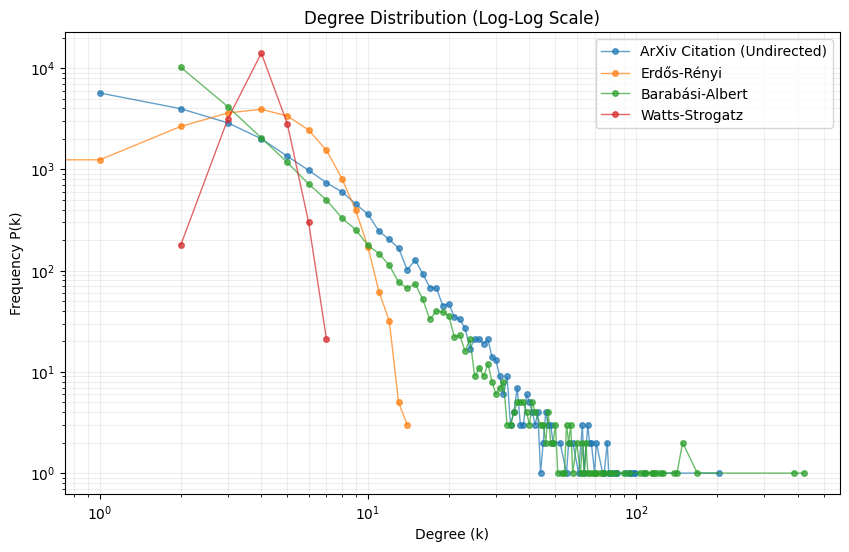

In [14]:
graphs = [G_undir, erdos, barabasi, watts]
labels = ["ArXiv Citation (Undirected)", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

network_utils.plot_degree_distribution(graphs, labels)

We see that ArXiv Citations network follows Barabasi-Albert Degree Distribution so it means that the Network is scale-free.

In [15]:
df_watts = network_utils.describe_network_undirected(watts)

In [16]:
df_barabasi = network_utils.describe_network_undirected(barabasi)

In [17]:
df_erdos = network_utils.describe_network_undirected(erdos)

In [18]:
df_citations = network_utils.describe_network_undirected(G_undir)

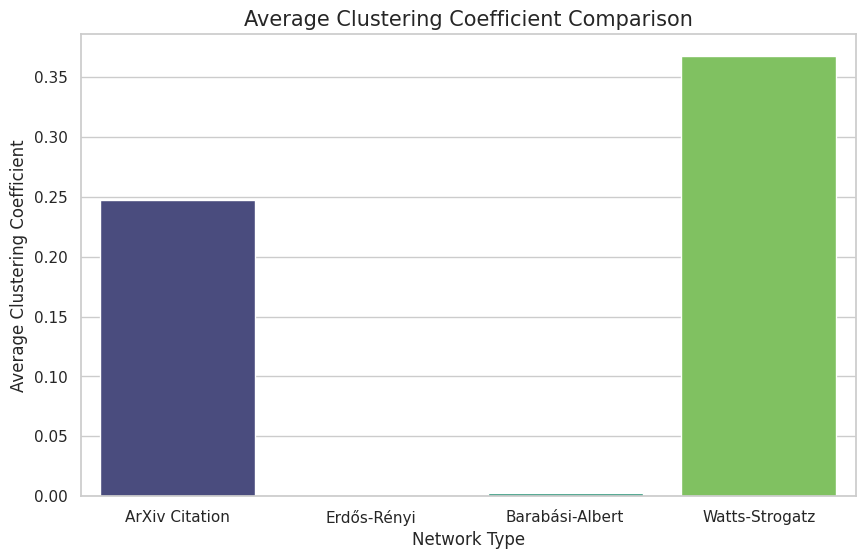

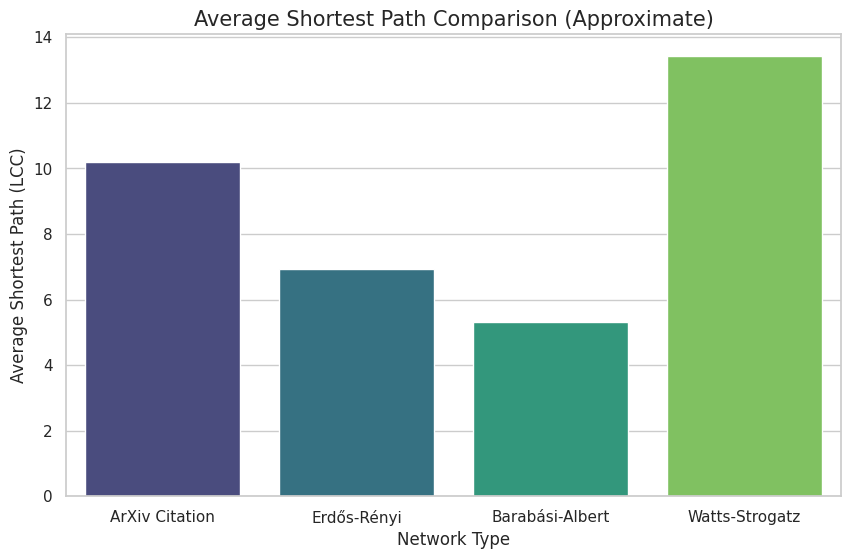

In [19]:
results = pd.concat([df_citations, df_erdos, df_barabasi, df_watts], ignore_index=True)
results['Network'] = ["ArXiv Citation", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Plot 1: Average Clustering Coefficient
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Network', y='Average Clustering Coefficient', hue='Network', palette='viridis', legend=False)
plt.title('Average Clustering Coefficient Comparison', fontsize=15)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.xlabel('Network Type', fontsize=12)
plt.show()

# Plot 2: Average Shortest Path
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Network', y='Average Shortest Path', hue='Network', palette='viridis', legend=False)
plt.title('Average Shortest Path Comparison (Approximate)', fontsize=15)
plt.ylabel('Average Shortest Path (LCC)', fontsize=12)
plt.xlabel('Network Type', fontsize=12)
plt.show()

In [20]:
results

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path,Network
0,20515,44119,4.301146,965,0.247071,16874,10.201720,ArXiv Citation
1,20515,44119,4.301146,275,0.000293,20229,6.941863,Erdős-Rényi
2,20515,41026,3.999610,1,0.002704,20515,5.322561,Barabási-Albert
3,20515,41030,4.000000,1,0.367264,20515,13.423213,Watts-Strogatz


### Centrality Measures to identify the most impactful papers

In [21]:
titleabs_df = pd.read_csv(
    "titleabs.tsv", 
    sep="\t", 
    header=None, 
    names=["paper id", "title", "abstract"]
)

titleabs_df["paper id"] = titleabs_df["paper id"].astype(int)
titleabs_df = titleabs_df.merge(labels_merged[["paper id", "arxiv category"]], on="paper id")

titleabs_indexed = titleabs_df.set_index("paper id")
titleabs_indexed.head()

,title,abstract,arxiv category
paper id,,,
630234,spreadsheets on the move an evaluation of mobi...,The power of mobile devices has increased dram...,arxiv cs hc
803423,multi view metric learning for multi view vide...,Traditional methods on video summarization are...,arxiv cs cv
1102481,big data analytics in future internet of things,Current research on Internet of Things (IoT) m...,arxiv cs dc
1532644,machine learner for automated reasoning 0 4 an...,Machine Learner for Automated Reasoning (MaLAR...,arxiv cs lg
1810480,cryptographic hardening of d sequences,This paper shows how a one-way mapping using m...,arxiv cs cr


In [22]:
pagerank = nx.pagerank(G)
pagerank_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, pagerank, "pagerank", node_mapping)

In [23]:
degree = nx.in_degree_centrality(G)
degree_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, degree, "degree", node_mapping)


In [24]:
betweenness = nx.betweenness_centrality(G, k=1000, seed=23)
betweenness_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, betweenness, "betweenness", node_mapping)

In [25]:
pagerank_ranking

,title,abstract,arxiv category
paper id,,,
1575405595,wireless network information flow,We present an achievable rate for general dete...,arxiv cs it
2952296444,subspace pursuit for compressive sensing signa...,We propose a new method for reconstruction of ...,arxiv cs na
2949320653,nonmonotonic reasoning preferential models and...,Many systems that exhibit nonmonotonic behavio...,arxiv cs ai
2951560945,bayesian compressive sensing via belief propag...,Compressive sensing (CS) is an emerging field ...,arxiv cs it
2952937400,gaussian interference channel capacity to with...,The capacity of the two-user Gaussian interfer...,arxiv cs it
1802395297,a deterministic approach to wireless relay net...,We present a deterministic channel model which...,arxiv cs it
2953139962,approximately universal codes over slow fading...,Performance of reliable communication over a c...,arxiv cs it
2949098898,what does a conditional knowledge base entail,This paper presents a logical approach to nonm...,arxiv cs ai
2951037137,mimo broadcast channels with finite rate feedback,Multiple transmit antennas in a downlink chann...,arxiv cs it


Interestingly, the Information Theory category represents 75% of the most important papers computed by PageRank.
The papers mostly focus on error-correcting coding, wireless networks and interference within them and information compression.

In [26]:
degree_ranking

,title,abstract,arxiv category
paper id,,,
2952937400,gaussian interference channel capacity to with...,The capacity of the two-user Gaussian interfer...,arxiv cs it
2109962983,wireless network information flow a determinis...,In a wireless network with a single source and...,arxiv cs it
2949549882,coding for errors and erasures in random netwo...,The problem of error-control in random linear ...,arxiv cs it
2949959192,exact matrix completion via convex optimization,We consider a problem of considerable practica...,arxiv cs it
2951040947,capacity bounds for the gaussian interference ...,The capacity region of the two-user Gaussian I...,arxiv cs it
2950160365,mutual information and minimum mean square err...,This paper deals with arbitrarily distributed ...,arxiv cs it
2110115072,a new outer bound and the noisy interference s...,A new outer bound on the capacity region of Ga...,arxiv cs it
2949589069,cognitive radio an information theoretic persp...,Cognitive radios have been proposed as a means...,arxiv cs it
2951037137,mimo broadcast channels with finite rate feedback,Multiple transmit antennas in a downlink chann...,arxiv cs it


In the Degree centrality it's even more prominent. The reasons are similar but something else might be also true. That the community of information theory, wireless communication, coding really stood out as the most writing and citing community in the 2000s. It was probably really dense and shows that many people at the time were focused on solving WiFi and wireless communication. It is also the time when 3G and LTE started appearing.

In [27]:
betweenness_ranking

,title,abstract,arxiv category
paper id,,,
2951278247,ergodic interference alignment,This paper develops a new communication strate...,arxiv cs it
2952319259,compute and forward harnessing interference th...,Interference is usually viewed as an obstacle ...,arxiv cs it
2951927428,guaranteed rank minimization via singular valu...,Minimizing the rank of a matrix subject to aff...,arxiv cs lg
2951660154,a learning theory approach to non interactive ...,"In this paper we demonstrate that, ignoring co...",arxiv cs ds
2951475295,a regularity lemma and low weight approximator...,"We give a ""regularity lemma"" for degree-d poly...",arxiv cs cc
2949834189,matrix completion from a few entries,Let M be a random (alpha n) x n matrix of rank...,arxiv cs lg
2950665404,agnostic learning of monomials by halfspaces i...,We prove the following strong hardness result ...,arxiv cs cc
2951119348,a complete characterization of statistical que...,Statistical query (SQ) learning model of Kearn...,arxiv cs cc
2949758198,what can we learn privately,Learning problems form an important category o...,arxiv cs lg


Betweenness centrality however shows different nodes. It mostly focuses on bridges that are nodes connecting multiple Computer Science areas and are generally most important for Computer Science in general rather than being really important only for a subgroup of categories.

### Community Detection

Now we will explore if it is possible to group the nodes into communities (categories) based on network structure alone, so that
the detected communities overlap with ArXiV Computer Science paper categories.
For that we will use well-known algorithms for Community Detection.

In [53]:
import importlib
importlib.reload(network_utils)

<module 'network_utils' from '/home/husz/ass/Citations-Network/network_utils.py'>

In [66]:
lcc_nodes = max(nx.weakly_connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes)
louvain_communities = nx.community.louvain_communities(G_lcc)

louvain_modularity, louvain_results = network_utils.evaluate_communities(
    G_lcc, louvain_communities, labels_merged[["node idx", "arxiv category"]]

)

print(f"Modularity of Louvain: {louvain_modularity:.4f}")
print(f"Average purity of dominating category: {louvain_results['percentage'].mean():.4f}")
print(f"Standard deviation of purity of dominating category: {louvain_results['percentage'].std():.4f}")
domination_count = louvain_results[louvain_results["percentage"] > 0.4]["percentage"].count()
print(f"Number of communities where purity of max category is bigger than 40%: {domination_count}")
louvain_results


Modularity of Louvain: 0.8943
Average purity of dominating category: 0.5684
Standard deviation of purity of dominating category: 0.2029
Number of communities where purity of max category is bigger than 40%: 52


,max category,percentage
11,arxiv cs ai,1.000000
57,arxiv cs it,1.000000
12,arxiv cs it,0.972868
29,arxiv cs it,0.950704
40,arxiv cs it,0.937500
...,...,...
34,arxiv cs lg,0.318777
55,arxiv cs db,0.309091
16,arxiv cs pl,0.295775
17,arxiv cs cc,0.284916


In [55]:
label_prop_communities = list(nx.community.fast_label_propagation_communities(G_lcc))
label_prop_modularity, label_prop_results = network_utils.evaluate_communities(
    G_lcc, label_prop_communities, labels_merged[["node idx", "arxiv category"]]
)

print(f"Modularity of Label Propagation: {label_prop_modularity:.4f}")
label_prop_results


Modularity of Label Propagation: 0.7542


,max category,percentage
12,arxiv cs cc,1.000000
2016,arxiv cs ds,1.000000
1977,arxiv cs ni,1.000000
1978,arxiv cs cc,1.000000
1979,arxiv cs dc,1.000000
...,...,...
168,arxiv cs gt,0.250000
80,arxiv cs cv,0.205882
946,arxiv cs ce,0.200000
919,arxiv cs ni,0.200000


In [37]:
louvain_communities = nx.community.louvain_communities(G)
louvain_modularity, louvain_results = network_utils.evaluate_communities(
    G, louvain_communities, labels_merged[["node idx", "arxiv category"]]

)

print(f"Modularity of Louvain: {louvain_modularity:.4f}")
louvain_results


Modularity of Louvain: 0.9060


,max category,percentage
0,arxiv cs ni,1.000000
1,arxiv cs et,0.285714
2,arxiv cs et,1.000000
3,arxiv cs na,0.666667
4,arxiv cs se,1.000000
...,...,...
1030,arxiv cs cv,1.000000
1031,arxiv cs se,0.923077
1032,arxiv cs ni,1.000000
1033,arxiv cs se,1.000000
